In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/insurance.csv'
df = pd.read_csv(file_path)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


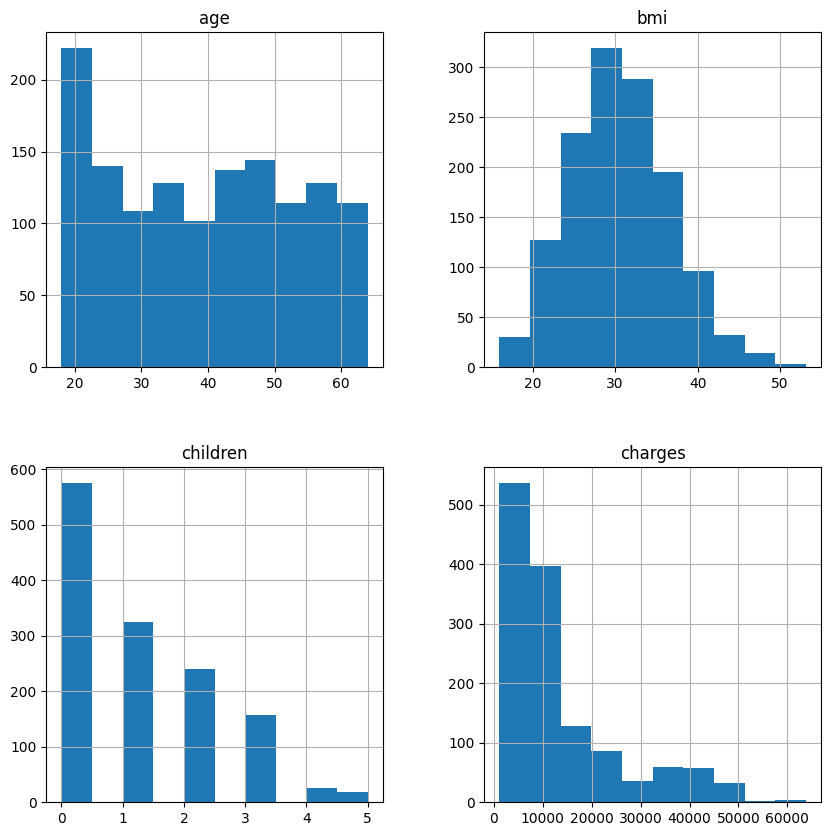

In [ ]:
df.hist(figsize=(10, 10))
plt.show()

<Axes: xlabel='age', ylabel='bmi'>

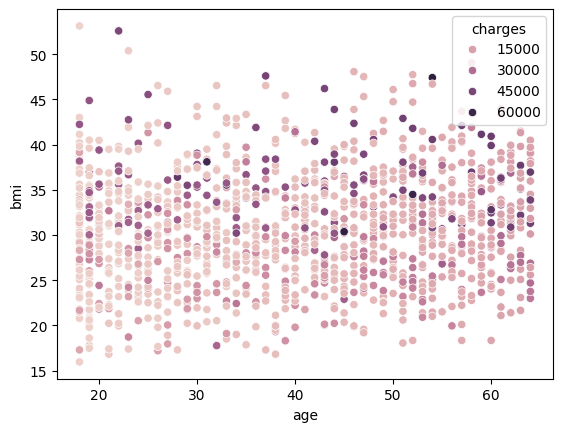

In [ ]:
sns.scatterplot(data=df, x="age", y="bmi", hue="charges")

In [ ]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [ ]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [ ]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
df['sex'] = df['sex'].replace('female','0')
df['sex'] = df['sex'].replace('male','1')

df['smoker'] = df['smoker'].replace('yes','0')
df['smoker'] = df['smoker'].replace('no','1')

df['region'] = df['region'].replace('southwest','0')
df['region'] = df['region'].replace('southeast','1')
df['region'] = df['region'].replace('northwest','2')
df['region'] = df['region'].replace('northeast','3')

In [ ]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
df['sex']=pd.to_numeric(df['sex'])
df['smoker']=pd.to_numeric(df['smoker'])
df['region']=pd.to_numeric(df['region'])


<Axes: >

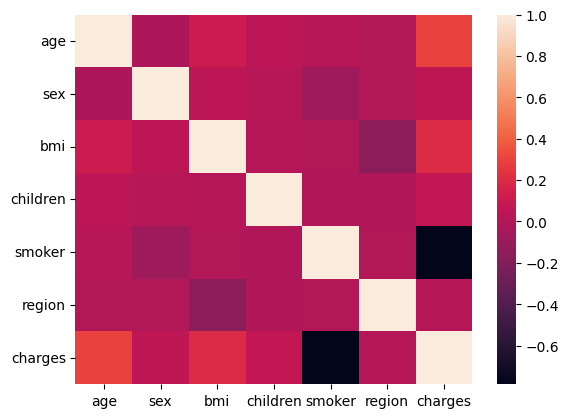

In [ ]:
sns.heatmap(df.corr(),fmt='.2g')

In [ ]:
df.dtypes

,0
age,int64
sex,int64
bmi,float64
children,int64
smoker,int64
region,int64
charges,float64


In [ ]:
x = df.drop('charges',axis=1)
y = df['charges']

In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

DECISON TREE REGRESSOR

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dtree = DecisionTreeRegressor(random_state=0)
dtree.fit(x_train,y_train)

DecisionTreeRegressor(random_state=0)

In [ ]:
y_pred = dtree.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score
print("Decision Tree Regression R2 Score: ", r2_score(y_test, y_pred))

Decision Tree Regression R2 Score:  0.7636846765717267


In [ ]:
from sklearn import metrics
import math
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
rmse = math.sqrt(mse)

print(f'MAE is: {mae}')
print(f'MSE is: {mse}')
print(f'R2 score is: {r2}')
print(f'RMSE score is: {rmse}')

MAE is: 2778.5646489141795
MSE is: 36687654.1943076
R2 score is: 0.7636846765717267
RMSE score is: 6057.033448339839


In [ ]:
iage = int(input("Enter your age: "))
isex = input("Enter youyr sex : (male/female) : ")
ibmi = float(input("Enter your BMI: "))
ichild = int(input("Enter no of CHILDREN: "))
ismoke = input("Do you smoke? (yes/no): ")
ireg = input("Enter region: ")

sex_map = {'male': 1, 'female': 0}
smoke_map = {'yes': 0, 'no': 1}
reg_map = {'southwest':0, 'southeast':1, 'northwest':2, 'northeast':3}

n_sex = sex_map.get(isex)
n_smoke = smoke_map.get(ismoke)
n_reg = reg_map.get(ireg)

if any(val is None for val in [n_sex, n_smoke, n_reg]):
    print("Error: One or more input categories not found in the mapping. Please check your spelling and available options.")
else:
    new_input_df = pd.DataFrame([[iage, n_sex, ibmi,ichild,n_smoke,n_reg]],
                                 columns=x.columns)
    scaled_new_input = scaler.transform(new_input_df)
    prediction = dtree.predict(scaled_new_input)
    print(f"Predicted price: {prediction[0]:.2f}")

Enter your age: 18
Enter youyr sex : (male/female) : male
Enter your BMI: 33.77
Enter no of CHILDREN: 1
Do you smoke? (yes/no): no
Enter region: southeast
Predicted price: 1842.52
